Creating combined nested donut chart for RQ1.2...


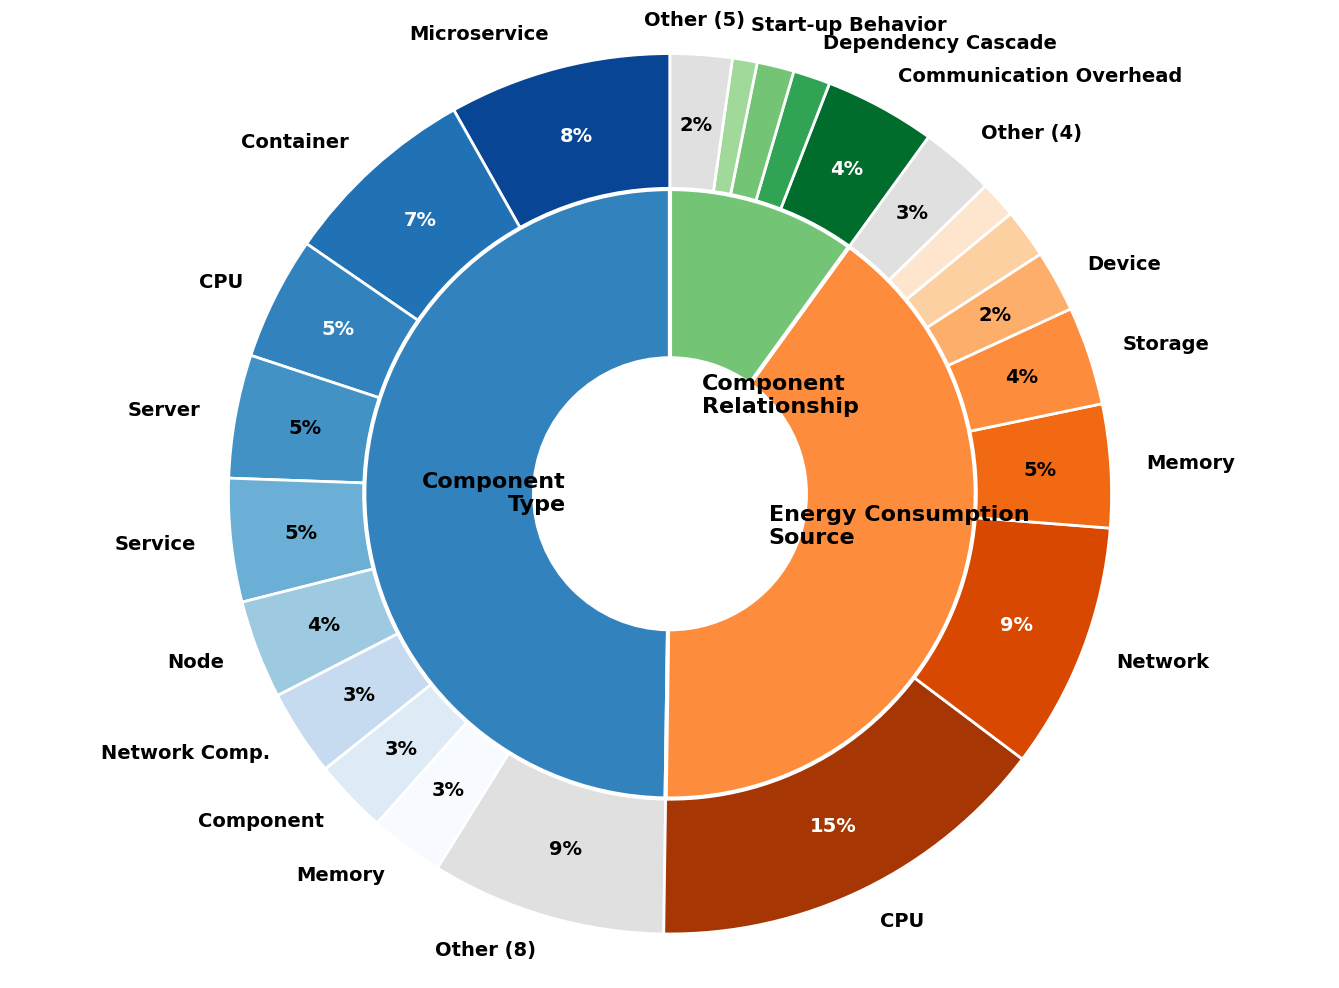

✓ Combined nested donut saved to: output/rq1.2_nested_combined.pdf

Inner ring totals:
  Component Type: 110 items
  Energy Consumption Source: 89 items
  Component Relationship: 22 items

NESTED DONUT CHART DATA - RQ1.2 (Copy/Paste Format)

INNER RING (Main Categories):
----------------------------------------
  Component Type: 110 items
  Energy Consumption Source: 89 items
  Component Relationship: 22 items


OUTER RING (Subcategories by Main Category):
----------------------------------------

1. COMPONENT TYPE (110 items total - Items ≥6 + Other):
   - Microservice: 18 (16.36%)
   - Container: 16 (14.55%)
   - CPU: 10 (9.09%)
   - Server: 10 (9.09%)
   - Service: 10 (9.09%)
   - Node: 8 (7.27%)
   - NetworkComponent: 7 (6.36%)
   - Component: 6 (5.45%)
   - Memory: 6 (5.45%)
   - Other (Device(4), Pod(4), Gateway(3), Orchestrator(2), Storage(2), VirtualMachine(2), LoadBalancer(1), MonitoringComponent(1)): 19 (17.27%)

2. ENERGY CONSUMPTION SOURCE (89 items total - Items ≥3 + Other

In [3]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import os

# Create output directory if it doesn't exist
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

# Combined nested donut chart showing all three parameters
print("Creating combined nested donut chart for RQ1.2...")

# Prepare data for nested donut
# Inner ring: three main categories
inner_labels = [
    'Component\nType',
    'Energy Consumption\nSource',
    'Component\nRelationship'
 ]
inner_sizes = [110, 89, 22]  # Total counts for each category
inner_colors = ['#3182bd', '#fd8d3c', '#74c476']

# Outer ring: simplified for readability in publication
outer_labels = (
    # ComponentType (items >= 6 + other)
    [
        'Microservice', 'Container', 'CPU', 'Server', 'Service',
        'Node', 'Network Comp.', 'Component', 'Memory', 'Other (8)'
    ] +
    # EnergyConsumptionSource (items >= 3 + other)
    [
        'CPU', 'Network', 'Memory', 'Storage', 'Device', 'Server',
        'Computation', 'Other (4)'
    ] +
    # ComponentRelationship (items >= 2 + other)
    [
        'Communication Overhead', 'Dependency Cascade',
        'Placement Dependency', 'Start-up Behavior', 'Other (5)'
    ]
)

outer_sizes = (
    # ComponentType: >=6, other includes Device(4), Pod(4), Gateway(3), Orchestrator(2), Storage(2), VirtualMachine(2), LoadBalancer(1), MonitoringComponent(1)
    [18, 16, 10, 10, 10, 8, 7, 6, 6, 19] +
    # EnergyConsumptionSource: >=3, other includes IdlePower(2), PowerSupply(2), FPGA(1), MaxPower(1)
    [33, 20, 10, 8, 5, 4, 3, 6] +
    # ComponentRelationship: >=2, other includes Reconfiguration(1), RedundancyReplication(1), RequestBatching(1), ServiceDeactivation(1), SharedResourceContention(1)
    [9, 3, 3, 2, 5]
)

# Colors for outer ring - gradient within each category
outer_colors = (
    # ComponentType - blue gradient (10 colors)
    ['#084594', '#2171b5', '#3182bd', '#4292c6', '#6baed6', '#9ecae1', '#c6dbef', '#deebf7', '#f7fbff', '#e0e0e0'] +
    # EnergyConsumptionSource - orange gradient (8 colors)
    ['#a63603', '#d94801', '#f16913', '#fd8d3c', '#fdae6b', '#fdd0a2', '#fee6ce', '#e0e0e0'] +
    # ComponentRelationship - green gradient (5 colors)
    ['#006d2c', '#31a354', '#74c476', '#a1d99b', '#e0e0e0']
)

component_relationship_start = 18
component_relationship_indices = list(range(component_relationship_start, len(outer_labels)))
hidden_label_indices = {20}  # Hide Placement Dependency to avoid overlap


def is_dark_color(rgba, threshold=0.5):
    r, g, b, _ = rgba
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return luminance < threshold


# Create figure
fig, ax = plt.subplots(figsize=(13.5, 10))

# Create labels - keep the original style, but always show Component Relationship labels
total_items = sum(outer_sizes)
display_labels = [
    '' if idx in hidden_label_indices else (
        label if ((size / total_items) * 100 >= 2 or idx in component_relationship_indices) else ''
    )
    for idx, (label, size) in enumerate(zip(outer_labels, outer_sizes))
]

# Plot outer ring (subcategories)
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    outer_sizes,
    labels=display_labels,
    autopct=lambda pct: f'{pct:.0f}%' if pct >= 2 else '',
    radius=1.3,
    colors=outer_colors,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 14, 'fontweight': 'bold', 'color': 'black', 'wrap': False},
    pctdistance=0.84,
    labeldistance=1.08,
    startangle=90
)

# Plot inner ring (main categories)
wedges_inner, texts_inner = ax.pie(
    inner_sizes,
    labels=inner_labels,
    radius=0.9,
    colors=inner_colors,
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 3},
    textprops={'fontsize': 16, 'fontweight': 'bold', 'color': 'black', 'wrap': True},
    labeldistance=0.34,
    startangle=90
)

# Keep outer labels black and prevent wrapping
for text in texts_outer:
    if text.get_text():
        text.set_color('black')
        text.set_wrap(False)

# Set percentage text color for contrast: white on dark wedges, black otherwise
for wedge, autotext in zip(wedges_outer, autotexts_outer):
    if autotext.get_text():
        autotext.set_color('white' if is_dark_color(wedge.get_facecolor()) else 'black')
        autotext.set_wrap(False)

for text in texts_inner:
    text.set_color('black')
    text.set_wrap(True)

# Move the Component Relationship 'Other' label 40 px to the left
for text in texts_outer:
    if text.get_text() == 'Other (5)':
        offset = mtransforms.ScaledTranslation(-60 / fig.dpi, 0, fig.dpi_scale_trans)
        text.set_transform(text.get_transform() + offset)
        break

ax.axis('equal')
plt.tight_layout()

# Save the combined nested chart
nested_file_path = os.path.join(output_dir, 'rq1.2_nested_combined.pdf')
fig.savefig(nested_file_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"✓ Combined nested donut saved to: {nested_file_path}")
print("\nInner ring totals:")
print(f"  Component Type: {inner_sizes[0]} items")
print(f"  Energy Consumption Source: {inner_sizes[1]} items")
print(f"  Component Relationship: {inner_sizes[2]} items")

# Output data in copy-pasteable format
print("\n" + "=" * 80)
print("NESTED DONUT CHART DATA - RQ1.2 (Copy/Paste Format)")
print("=" * 80)
print("\nINNER RING (Main Categories):")
print("-" * 40)
for label, size in zip(inner_labels, inner_sizes):
    print(f"  {label.replace(chr(10), ' ')}: {size} items")

print("\n\nOUTER RING (Subcategories by Main Category):")
print("-" * 40)

print("\n1. COMPONENT TYPE (110 items total - Items ≥6 + Other):")
ct_labels = [
    'Microservice', 'Container', 'CPU', 'Server', 'Service',
    'Node', 'NetworkComponent', 'Component', 'Memory',
    'Other (Device(4), Pod(4), Gateway(3), Orchestrator(2), Storage(2), VirtualMachine(2), LoadBalancer(1), MonitoringComponent(1))'
 ]
ct_sizes = [18, 16, 10, 10, 10, 8, 7, 6, 6, 19]
for label, size in zip(ct_labels, ct_sizes):
    pct = (size / 110) * 100
    print(f"   - {label}: {size} ({pct:.2f}%)")

print("\n2. ENERGY CONSUMPTION SOURCE (89 items total - Items ≥3 + Other):")
ecs_labels = [
    'CPU', 'Network', 'Memory', 'Storage', 'Device', 'Server', 'Computation',
    'Other (IdlePower(2), PowerSupply(2), FPGA(1), MaxPower(1))'
 ]
ecs_sizes = [33, 20, 10, 8, 5, 4, 3, 6]
for label, size in zip(ecs_labels, ecs_sizes):
    pct = (size / 89) * 100
    print(f"   - {label}: {size} ({pct:.2f}%)")

print("\n3. COMPONENT RELATIONSHIP (22 items total - Items ≥2 + Other):")
cr_labels = [
    'CommunicationOverhead', 'DependencyCascade', 'PlacementDependency', 'StartUpBehavior',
    'Other (Reconfiguration(1), RedundancyReplication(1), RequestBatching(1), ServiceDeactivation(1), SharedResourceContention(1))'
 ]
cr_sizes = [9, 3, 3, 2, 5]
for label, size in zip(cr_labels, cr_sizes):
    pct = (size / 22) * 100
    print(f"   - {label}: {size} ({pct:.2f}%)")

print("\n" + "=" * 80)